
# Swarmy Visualization Demo – Matplotlib

Visualizes a Swarmy simulation using the MatplotlibRenderer inline in Jupyter.
**Requirements:** `matplotlib` and `swarmy` installed. Works best with `%matplotlib inline` or `%matplotlib notebook` enabled.
            

In [1]:
# --- Ensure no intermediate figures display ---
import matplotlib.pyplot as plt
plt.ioff()  # turn off interactive mode

import sys
from PIL import Image
from IPython.display import Image as IPyImage, display

# Add swarmy path if not installed system-wide
sys.path.append(r"C:\Users\miche\Documents\GitLab\swarmy")

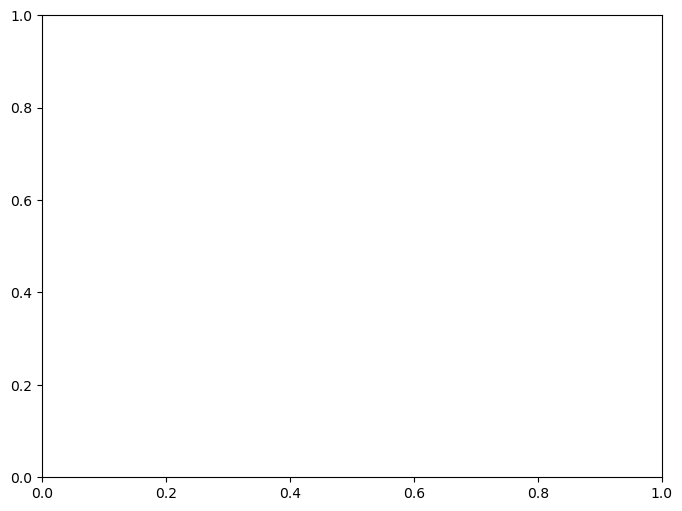

Step 0
Step 30
Step 60
Step 90
✅ GIF saved as swarm_simulation.gif


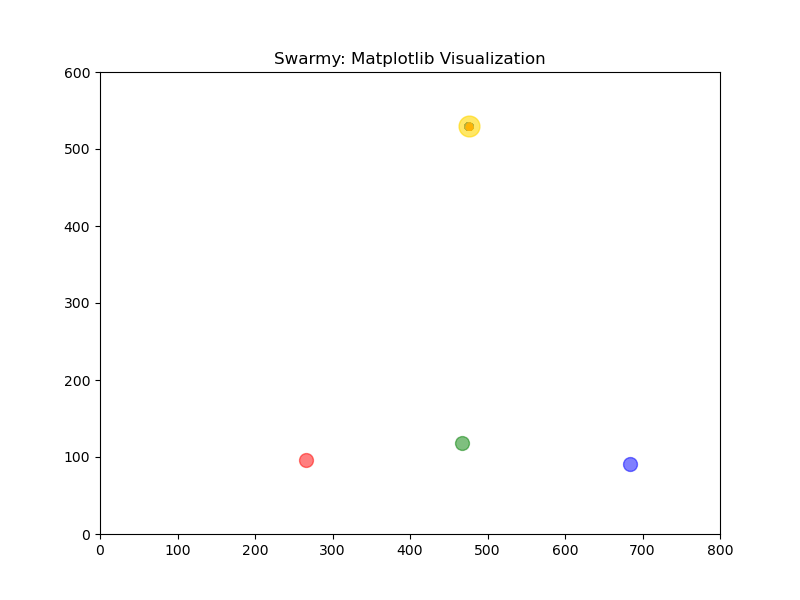

In [2]:
from swarmy import SwarmSimulation, SimulationConfig
from swarmy.visualization.matplotlib_renderer import MatplotlibRenderer

# --- Setup simulation ---
config = SimulationConfig(num_agents=30, num_scouts=5)
sim = SwarmSimulation(config)

# Create renderer; figure will not display due to plt.ioff()
renderer = MatplotlibRenderer(width=800, height=600)

frames = []

# --- Run simulation and capture frames ---
for step in range(120):
    sim.step()
    renderer.render(sim.get_state())

    # Capture the rendered figure
    fig = renderer.fig
    fig.canvas.draw()
    image = Image.frombytes('RGB', fig.canvas.get_width_height(),
                            fig.canvas.tostring_rgb())
    frames.append(image)

    if step % 30 == 0:
        print(f"Step {step}")

# --- Cleanup renderer figure to free memory ---
renderer.fig.clf()
renderer.fig.canvas.flush_events()

# --- Save as GIF ---
output_path = "swarm_simulation.gif"
frames[0].save(
    output_path,
    save_all=True,
    append_images=frames[1:],
    duration=100,  # milliseconds per frame
    loop=0
)

print(f"✅ GIF saved as {output_path}")

# --- Display the GIF inline ---
display(IPyImage(filename=output_path))